In [1]:
import numpy as np
import torch
import torch.nn as nn
import os
import matplotlib.pyplot as plt

m1 = 0.85
m2 = 0.518
m2_nom = 0.300

c1 = 10.0
cp = 4.0

k1 = 194e3
kp = 111e3
kp_nom = 50e3

e_pz = 0.65
C_p = 27e-6

R_true = 22.0
L_true = 64e-3

# choose a nearby but wrong value
R_nom = 20.0
L_nom = 50e-3

f_min_hz = 40.0
f_max_hz = 130.0
n_freq = 60

freq_hz = np.linspace(f_min_hz, f_max_hz, n_freq)
omega = 2.0 * np.pi * freq_hz
force_amp = 1.0

In [2]:
class SATMDFrequencyGroundTruth(nn.Module):
    def __init__(self, m1, m2, c1, cp, k1, kp, C_p, e_pz, R, L, force_amp=1.0):
        super().__init__()

        # parameters
        self.m1 = float(m1)
        self.m2 = float(m2)
        self.c1 = float(c1)
        self.cp = float(cp)
        self.k1 = float(k1)
        self.kp = float(kp)
        self.C_p = float(C_p)
        self.e_pz = float(e_pz)
        self.R = float(R)
        self.L = float(L)
        self.force_amp = float(force_amp)

    def dynamic_stiffness(self, omega, device=None, dtype=torch.complex64):

        # calculate the stifness matrix Z
        if not torch.is_tensor(omega):
            omega = torch.tensor(omega, dtype=torch.float32, device=device)

        omega = omega.to(device=device)
        j = torch.tensor(1j, dtype=dtype, device=device)

        w = omega.to(dtype=torch.float32)
        w2 = (w ** 2).to(dtype=torch.float32)

        m1 = self.m1
        m2 = self.m2
        c1 = self.c1
        cp = self.cp
        k1 = self.k1
        kp = self.kp
        C_p = self.C_p
        e = self.e_pz
        R = self.R
        L = self.L

        z11 = (k1 + kp - m1 * w2) + j * w * (c1 + cp)
        z12 = (-kp) - j * w * cp
        z13 = (e / C_p) * torch.ones_like(w, dtype=dtype)

        z21 = (-kp) - j * w * cp
        z22 = (kp - m2 * w2) + j * w * cp
        z23 = (-e / C_p) * torch.ones_like(w, dtype=dtype)

        z31 = (e / C_p) * torch.ones_like(w, dtype=dtype)
        z32 = (-e / C_p) * torch.ones_like(w, dtype=dtype)
        z33 = (1.0 / C_p - L * w2) + j * w * R

        # build the stiffness matrix
        Z = torch.stack([
            torch.stack([z11, z12, z13], dim=-1),
            torch.stack([z21, z22, z23], dim=-1),
            torch.stack([z31, z32, z33], dim=-1),
        ], dim=-2)

        return Z

    def forcing_vector(self, omega, device=None, dtype=torch.complex64):

        # calculates the forcing vector (in this case it is applied to the first DOF)
        if not torch.is_tensor(omega):
            omega = torch.tensor(omega, dtype=torch.float32, device=device)
        omega = omega.to(device=device)

        F = torch.zeros((*omega.shape, 3), dtype=dtype, device=device)
        F[..., 0] = self.force_amp
        return F

    def solve_frf(self, omega, device=None, dtype=torch.complex64):

        # solve the equation Z(omega) * X(omega) = F(omega)
        Z = self.dynamic_stiffness(omega, device=device, dtype=dtype)
        F = self.forcing_vector(omega, device=device, dtype=dtype)

        X = torch.linalg.solve(Z, F.unsqueeze(-1)).squeeze(-1)
        return X  # [..., 3] complex -> [U1, U2, Q2]

    def structural_accel_frf(self, omega, dtype=torch.complex64):

        X = self.solve_frf(omega, dtype=dtype)   # [U1, U2, Q2]
        U1 = X[..., 0]
        U2 = X[..., 1]

        w2 = (omega ** 2).to(U1.dtype)

        A1 = -w2 * U1
        A2 = -w2 * U2

        return torch.stack([A1, A2], dim=-1)

    def forward(self, omega):
        return self.solve_frf(omega)


class SATMDFrequencyRelativeParameterModel(nn.Module):
    def __init__(self,m1, m2_nom, c1, cp, k1, kp_nom, C_p, e_pz,R_nom, L_nom, force_amp=1.0):
        super().__init__()

        # parameters
        self.m1 = float(m1)
        self.c1 = float(c1)
        self.cp = float(cp)
        self.k1 = float(k1)
        self.C_p = float(C_p)
        self.e_pz = float(e_pz)
        self.force_amp = float(force_amp)

        # known parameters we want to optimize
        self.m2_nom = float(m2_nom)
        self.kp_nom = float(kp_nom)
        self.R_nom  = float(R_nom)
        self.L_nom  = float(L_nom)

        # correction of the parameters
        self.corr_m2 = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))
        self.corr_kp = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))
        self.corr_R  = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))
        self.corr_L  = nn.Parameter(torch.tensor(0.0, dtype=torch.float32))

    def effective_params(self):
        # add the correction to the initial value
        m2 = self.m2_nom * (1.0 + self.corr_m2)
        kp = self.kp_nom * (1.0 + self.corr_kp)
        R  = self.R_nom  * (1.0 + self.corr_R)
        L  = self.L_nom  * (1.0 + self.corr_L)
        return m2, kp, R, L

    def dynamic_stiffness(self, omega, dtype=torch.complex64):
        w = omega.to(torch.float32)
        w2 = w ** 2
        j = torch.tensor(1j, dtype=dtype, device=omega.device)

        m2, kp, R, L = self.effective_params()

        z11 = (self.k1 + kp - self.m1 * w2) + j * w * (self.c1 + self.cp)
        z12 = (-kp) - j * w * self.cp
        z13 = (self.e_pz / self.C_p) * torch.ones_like(w, dtype=dtype)

        z21 = (-kp) - j * w * self.cp
        z22 = (kp - m2 * w2) + j * w * self.cp
        z23 = (-self.e_pz / self.C_p) * torch.ones_like(w, dtype=dtype)

        z31 = (self.e_pz / self.C_p) * torch.ones_like(w, dtype=dtype)
        z32 = (-self.e_pz / self.C_p) * torch.ones_like(w, dtype=dtype)
        z33 = (1.0 / self.C_p - L * w2) + j * w * R

        Z = torch.stack([
            torch.stack([z11, z12, z13], dim=-1),
            torch.stack([z21, z22, z23], dim=-1),
            torch.stack([z31, z32, z33], dim=-1),
        ], dim=-2)

        return Z

    def forcing_vector(self, omega, dtype=torch.complex64):
        F = torch.zeros((*omega.shape, 3), dtype=dtype, device=omega.device)
        F[..., 0] = self.force_amp
        return F

    def solve_frf(self, omega, dtype=torch.complex64):

        # solve the equation Z(omega) * X(omega) = F(omega)
        Z = self.dynamic_stiffness(omega, dtype=dtype)
        F = self.forcing_vector(omega, dtype=dtype)
        X = torch.linalg.solve(Z, F.unsqueeze(-1)).squeeze(-1)
        return X # [..., 3] complex -> [U1, U2, Q2]

    def structural_accel_frf(self, omega, dtype=torch.complex64):

        X = self.solve_frf(omega, dtype=dtype)   # [U1, U2, Q2]
        U1 = X[..., 0]
        U2 = X[..., 1]

        w2 = (omega ** 2).to(U1.dtype)

        A1 = -w2 * U1
        A2 = -w2 * U2

        return torch.stack([A1, A2], dim=-1)

    def forward(self, omega):
        return self.solve_frf(omega)

In [3]:
dtype_real = torch.float32
dtype_complex = torch.complex64
device = "cpu"

omega_t = torch.tensor(omega, dtype=dtype_real, device=device)
freq_hz_t = torch.tensor(freq_hz, dtype=dtype_real, device=device)

groundtruth_model = SATMDFrequencyGroundTruth(m1=m1,m2=m2,c1=c1,cp=cp,k1=k1,kp=kp,C_p=C_p,e_pz=e_pz,R=R_true,L=L_true,force_amp=force_amp).to(device)

model = SATMDFrequencyRelativeParameterModel(m1=m1,m2_nom=m2_nom,c1=c1,cp=cp,k1=k1,kp_nom=kp_nom,C_p=C_p,e_pz=e_pz,R_nom=R_nom,L_nom=L_nom,force_amp=force_amp).to(device)

In [4]:
def train_frequency_model(model,groundtruth_model,omega_grid,epochs=5000,lr=1e-3,print_every=100,lambda_w=1e-8):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()

    with torch.no_grad():
        Y_true = groundtruth_model.solve_frf(omega_grid)

    for epoch in range(1, epochs + 1):
        optimizer.zero_grad()

        Y_pred = model.solve_frf(omega_grid)

        # bound the loss
        scale = Y_true.abs().max().detach().clamp_min(1e-8)
        loss_data = (mse(Y_pred.real / scale, Y_true.real / scale) +mse(Y_pred.imag /scale, Y_true.imag / scale))
        reg = torch.zeros((), device=omega_grid.device)
        for p in model.parameters():
            reg = reg + torch.sum(p**2)

        # data + regularizer
        loss = loss_data + lambda_w * reg
        loss.backward()
        optimizer.step()

        # re-calculate the correction
        m2_eff, kp_eff, R_eff, L_eff = model.effective_params()

        if epoch % print_every == 0 or epoch == 1:
            print(
                f"Epoch {epoch:5d} | "
                f"Loss = {loss.item():.6e} | "
                f"R = {R_eff.item():.6f} | "
                f"L = {L_eff.item():.6e} | "
                f"m2 = {m2_eff.item():.6f} | "
                f"kp = {kp_eff.item():.6f}"
            )

    return model

In [5]:
model.load_state_dict(torch.load("../models/electrical_exp4_correction_net.pth", map_location=device))
model.eval()

/tmp/ipykernel_1067/1304529300.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("../models/electrical_exp4_correction_net.pth", map_locat

SATMDFrequencyRelativeParameterModel()

In [6]:
model = train_frequency_model(
    model=model,
    groundtruth_model=groundtruth_model,
    omega_grid=omega_t,
    epochs=10000,
    lr=1e-3,
    print_every=100,
)

save_dir = "../models/"
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "electrical_exp4_correction_net.pth")
torch.save(model.state_dict(), save_path)

print(f"Saved model weights to: {save_path}")

Epoch     1 | Loss = 2.149681e-02 | R = 20.020000 | L = 4.995000e-02 | m2 = 0.299700 | kp = 50050.003906
Epoch   100 | Loss = 9.883741e-03 | R = 20.905886 | L = 4.543367e-02 | m2 = 0.280948 | kp = 53673.523438
Epoch   200 | Loss = 9.409195e-03 | R = 20.328938 | L = 4.286455e-02 | m2 = 0.286836 | kp = 54500.519531
Epoch   300 | Loss = 8.836177e-03 | R = 19.649670 | L = 3.980834e-02 | m2 = 0.293843 | kp = 55645.273438
Epoch   400 | Loss = 8.205477e-03 | R = 18.947050 | L = 3.656032e-02 | m2 = 0.301925 | kp = 56996.488281
Epoch   500 | Loss = 7.553604e-03 | R = 18.301065 | L = 3.326684e-02 | m2 = 0.310773 | kp = 58511.398438
Epoch   600 | Loss = 6.907961e-03 | R = 17.785730 | L = 3.004175e-02 | m2 = 0.320135 | kp = 60153.996094
Epoch   700 | Loss = 6.285970e-03 | R = 17.456726 | L = 2.698251e-02 | m2 = 0.329801 | kp = 61894.136719
Epoch   800 | Loss = 5.696226e-03 | R = 17.338600 | L = 2.417490e-02 | m2 = 0.339602 | kp = 63707.714844
Epoch   900 | Loss = 5.142025e-03 | R = 17.422054 | L =

In [6]:
with torch.no_grad():
    m2_eff, kp_eff, R_eff, L_eff = model.effective_params()

print("\nIdentified parameters")
print(f"R_est  = {R_eff.item()}")
print(f"L_est  = {L_eff.item()}")
print(f"m2_est = {m2_eff.item()}")
print(f"kp_est = {kp_eff.item()}")


Identified parameters
R_est  = 21.999980926513672
L_est  = 0.06399980932474136
m2_est = 0.5179994106292725
kp_est = 110999.796875


In [7]:
with torch.no_grad():
    Y_true = groundtruth_model.solve_frf(omega_t)
    Y_pred = model.solve_frf(omega_t)

rel_err = torch.linalg.norm(Y_pred - Y_true) / torch.linalg.norm(Y_true)
print("Relative FRF error:", rel_err.item())

Relative FRF error: 2.3477489321521716e-06


/home/sdi2100218/Thesis/Interpretable-Structural-Dynamics/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/sdi2100218/Thesis/Interpretable-Structural-Dynamics/.venv/lib/python3.11/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


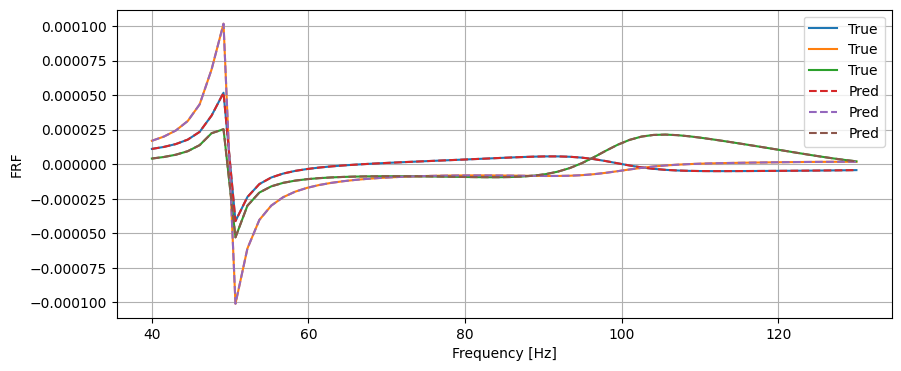

In [8]:
with torch.no_grad():
    Y_true = groundtruth_model.solve_frf(omega_t).cpu()
    Y_pred = model.solve_frf(omega_t).cpu()

plt.figure(figsize=(10,4))
plt.plot(freq_hz, Y_true.numpy(), label="True")
plt.plot(freq_hz, Y_pred.numpy(), "--", label="Pred")
plt.xlabel("Frequency [Hz]")
plt.ylabel("FRF")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# these are the 30 pairs for training
train_rl_pairs = [
    (5.0,   14e-3),
    (7.0,   26e-3),
    (11.0,  42e-3),
    (13.0,  48e-3),
    (15.0,  52e-3),
    (17.0,  64e-3),
    (19.0,  80e-3),
    (21.0,  92e-3),
    (23.0,  108e-3),
    (26.0,  116e-3),
    (27.0,  124e-3),
    (30.0,  148e-3),
    (34.0,  168e-3),
    (36.0,  184e-3),
    (40.0,  200e-3),
    (44.0,  212e-3),
    (46.0,  220e-3),
    (50.0,  236e-3),
    (54.0,  260e-3),
    (56.0,  272e-3),
    (62.0,  312e-3),
    (68.0,  336e-3),
    (70.0,  348e-3),
    (75.0,  372e-3),
    (78.0,  384e-3),
    (80.0,  392e-3),
    (88.0,  420e-3),
    (90.0,  432e-3),
    (92.0,  448e-3),
    (98.0,  480e-3),
]

In [10]:
def acceleration_to_features(acc):

    acc_real = acc.real.reshape(-1)
    acc_imag = acc.imag.reshape(-1)
    return torch.cat([acc_real, acc_imag], dim=0)

In [11]:
@torch.no_grad()
def build_inverse_acc_dataset(model_ctor,fixed_params,omega_grid,train_rl_pairs,samples_per_pair=200,R_jitter=2.0,L_jitter=10e-3,device="cpu",dtype=torch.complex64):
    omega_grid = omega_grid.to(device)

    X_list = []
    acc_list = []
    RL_list = []

    R_values = [p[0] for p in train_rl_pairs]
    L_values = [p[1] for p in train_rl_pairs]

    norm_info = {
        "R_min": max(0.0, min(R_values) - 5.0),
        "R_max": max(R_values) + 5.0,
        "L_min": max(0.0, min(L_values) - 20e-3),
        "L_max": max(L_values) + 20e-3,
    }

    for R0, L0 in train_rl_pairs:
        for _ in range(samples_per_pair):
            R = R0 + torch.empty(1).uniform_(-R_jitter, R_jitter).item()
            L = L0 + torch.empty(1).uniform_(-L_jitter, L_jitter).item()

            R = max(0.0, R)
            L = max(0.0, L)

            sys = model_ctor(**fixed_params, R=R, L=L).to(device)
            acc = sys.structural_accel_frf(omega_grid, dtype=dtype)

            feat = acceleration_to_features(acc)

            X_list.append(feat)
            acc_list.append(acc)
            RL_list.append(torch.tensor([R, L], dtype=torch.float32, device=device))

    X = torch.stack(X_list, dim=0)
    acc_all = torch.stack(acc_list, dim=0)
    RL_true = torch.stack(RL_list, dim=0)

    return X, acc_all, RL_true, norm_info

In [12]:
class RLInverseNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 2),
            nn.Sigmoid(),   # outputs normalized R,L in [0,1]
        )

    def forward(self, x):
        return self.net(x)

In [13]:
def denormalize_RL(pred_norm, norm_info):
    R = pred_norm[:, 0] * (norm_info["R_max"] - norm_info["R_min"]) + norm_info["R_min"]
    L = pred_norm[:, 1] * (norm_info["L_max"] - norm_info["L_min"]) + norm_info["L_min"]
    return R, L

In [14]:
def structural_accel_from_RL(omega, fixed_params, R, L, dtype=torch.complex64):

        m1   = fixed_params["m1"]
        m2   = fixed_params["m2"]
        c1   = fixed_params["c1"]
        cp   = fixed_params["cp"]
        k1   = fixed_params["k1"]
        kp   = fixed_params["kp"]
        C_p  = fixed_params["C_p"]
        e_pz = fixed_params["e_pz"]
        force_amp = fixed_params["force_amp"]

        w = omega.to(torch.float32)
        w2 = w ** 2
        j = torch.tensor(1j, dtype=dtype, device=omega.device)

        z11 = (k1 + kp - m1 * w2) + j * w * (c1 + cp)
        z12 = (-kp) - j * w * cp
        z13 = (e_pz / C_p) * torch.ones_like(w, dtype=dtype)

        z21 = (-kp) - j * w * cp
        z22 = (kp - m2 * w2) + j * w * cp
        z23 = (-e_pz / C_p) * torch.ones_like(w, dtype=dtype)

        z31 = (e_pz / C_p) * torch.ones_like(w, dtype=dtype)
        z32 = (-e_pz / C_p) * torch.ones_like(w, dtype=dtype)
        z33 = (1.0 / C_p - L * w2) + j * w * R

        Z = torch.stack([
            torch.stack([z11, z12, z13], dim=-1),
            torch.stack([z21, z22, z23], dim=-1),
            torch.stack([z31, z32, z33], dim=-1),
        ], dim=-2)

        F = torch.zeros((omega.shape[0], 3), dtype=dtype, device=omega.device)
        F[:, 0] = force_amp

        X = torch.linalg.solve(Z, F.unsqueeze(-1)).squeeze(-1)
        U1 = X[:, 0]
        U2 = X[:, 1]

        A1 = -(w2.to(U1.dtype)) * U1
        A2 = -(w2.to(U2.dtype)) * U2

        return torch.stack([A1, A2], dim=-1)

In [15]:
def train_inverse_via_acceleration_loss(model,X_train,acc_train,omega_grid,fixed_params,norm_info,epochs=300,lr=1e-3,print_every=20):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    mse = nn.MSELoss()

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        train_loss = 0.0

        for i in range(X_train.shape[0]):
            x = X_train[i:i+1]
            acc_true = acc_train[i]

            pred_norm = model(x)
            R_pred, L_pred = denormalize_RL(pred_norm, norm_info)

            acc_pred = structural_accel_from_RL(omega=omega_grid,fixed_params=fixed_params,R=R_pred[0],L=L_pred[0])

            scale = acc_true.abs().max().detach().clamp_min(1e-8)

            loss_i = (mse(acc_pred.real / scale, acc_true.real / scale) + mse(acc_pred.imag / scale, acc_true.imag / scale))

            train_loss = train_loss + loss_i

        train_loss = train_loss / X_train.shape[0]
        train_loss.backward()
        optimizer.step()


        if epoch % print_every == 0 or epoch == 1:
            print(
                f"Epoch {epoch:4d} | "
                f"train_loss = {train_loss.item():.6e} | "
            )

    return model

In [16]:
@torch.no_grad()
def predict_RL_from_acceleration(model, acc_curve, norm_info):

    feat = acceleration_to_features(acc_curve).unsqueeze(0)
    pred_norm = model(feat).squeeze(0)

    R_pred = pred_norm[0].item() * (norm_info["R_max"] - norm_info["R_min"]) + norm_info["R_min"]
    L_pred = pred_norm[1].item() * (norm_info["L_max"] - norm_info["L_min"]) + norm_info["L_min"]

    return R_pred, L_pred

In [17]:
fixed_params = dict(m1=m1,m2=m2,c1=c1,cp=cp,k1=k1,kp=kp,C_p=C_p,e_pz=e_pz,force_amp=force_amp)

X, acc, y, norm_info = build_inverse_acc_dataset(model_ctor=SATMDFrequencyGroundTruth,fixed_params=fixed_params,omega_grid=omega_t,train_rl_pairs=train_rl_pairs,samples_per_pair=5,R_jitter=2.0,L_jitter=10e-3,device=device)

In [18]:
n = X.shape[0]
perm = torch.randperm(n, device=X.device)

n_train = int(0.8 * n)
train_idx = perm[:n_train]
val_idx   = perm[n_train:]

X_train, acc_train, y_train = X[train_idx], acc[train_idx], y[train_idx]
X_val, acc_val, y_val = X[val_idx], acc[val_idx], y[val_idx]

In [19]:
regressor = RLInverseNet(input_dim=X.shape[1]).to(device)

In [ ]:
regressor = train_inverse_via_acceleration_loss(model=regressor,X_train=X_train, acc_train=acc_train,omega_grid = omega_t,fixed_params=fixed_params,norm_info=norm_info,epochs=5000,lr=5e-4,print_every=20)

# save the model
save_dir = "../models/"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "rl_inverse_net_1_256_5000_V2.pth")
torch.save(regressor.state_dict(), save_path)

Epoch    1 | train_loss = 2.953524e-02 | 
Epoch   20 | train_loss = 3.805458e-04 | 
Epoch   40 | train_loss = 1.501165e-04 | 
Epoch   60 | train_loss = 8.386824e-05 | 
Epoch   80 | train_loss = 6.993073e-05 | 
Epoch  100 | train_loss = 6.243221e-05 | 
Epoch  120 | train_loss = 8.064222e-05 | 
Epoch  140 | train_loss = 5.304752e-05 | 
Epoch  160 | train_loss = 4.941337e-05 | 
Epoch  180 | train_loss = 4.546583e-05 | 
Epoch  200 | train_loss = 4.260322e-05 | 
Epoch  220 | train_loss = 4.013191e-05 | 
Epoch  240 | train_loss = 4.325069e-05 | 
Epoch  260 | train_loss = 3.583511e-05 | 
Epoch  280 | train_loss = 3.248629e-05 | 
Epoch  300 | train_loss = 4.458272e-05 | 
Epoch  320 | train_loss = 2.941110e-05 | 
Epoch  340 | train_loss = 2.819336e-05 | 
Epoch  360 | train_loss = 2.520063e-05 | 
Epoch  380 | train_loss = 3.342360e-05 | 
Epoch  400 | train_loss = 2.487114e-05 | 
Epoch  420 | train_loss = 2.266037e-05 | 
Epoch  440 | train_loss = 1.831353e-05 | 
Epoch  460 | train_loss = 1.693582

In [177]:
# save the model
save_dir = "../models/"
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, "rl_inverse_net_5_256_5000.pth")
torch.save(regressor.state_dict(), save_path)

In [21]:
# load the model
save_dir = "../models/"
save_path = os.path.join(save_dir, "rl_inverse_net_5_256_5000.pth")
state_dict = torch.load(save_path, map_location=torch.device("cpu"))
regressor.load_state_dict(state_dict)

/tmp/ipykernel_1067/2724635019.py:4: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(save_path, map_location=torch.device("cpu"))


<All keys matched successfully>

In [22]:
eval_rl_pairs = [
    (8.0,  32e-3),
    (10.0, 50e-3),
    (22.0, 64e-3),
    (25.0, 100e-3),
    (35.0, 192e-3),
    (60.0, 300e-3),
]

In [23]:
@torch.no_grad()
def evaluate_on_pairs(model,model_ctor,fixed_params,omega_grid,eval_rl_pairs,norm_info,device="cpu"):
    results = []

    model.eval()

    for R_true, L_true in eval_rl_pairs:
        sys = model_ctor(**fixed_params,R=R_true,L=L_true).to(device)

        acc_true = sys.structural_accel_frf(omega_grid)

        R_pred, L_pred = predict_RL_from_acceleration(model=model,acc_curve=acc_true,norm_info=norm_info)

        results.append({
            "R_true": R_true,
            "L_true": L_true,
            "R_pred": R_pred,
            "L_pred": L_pred,
            "R_abs_err": abs(R_pred - R_true),
            "L_abs_err": abs(L_pred - L_true),
        })

    return results

In [25]:
results = evaluate_on_pairs(
    model=regressor,
    model_ctor=SATMDFrequencyGroundTruth,
    fixed_params=fixed_params,
    omega_grid=omega_t,
    eval_rl_pairs=eval_rl_pairs,
    norm_info=norm_info,
    device=device,
)

for r in results:
    print(r)

{'R_true': 8.0, 'L_true': 0.032, 'R_pred': 8.070900298655033, 'L_pred': 0.031536541879177094, 'R_abs_err': 0.07090029865503311, 'L_abs_err': 0.00046345812082290716}
{'R_true': 10.0, 'L_true': 0.05, 'R_pred': 10.053515799343586, 'L_pred': 0.049561865627765656, 'R_abs_err': 0.05351579934358597, 'L_abs_err': 0.00043813437223434726}
{'R_true': 22.0, 'L_true': 0.064, 'R_pred': 21.95147803425789, 'L_pred': 0.06357713788747787, 'R_abs_err': 0.048521965742111206, 'L_abs_err': 0.0004228621125221266}
{'R_true': 25.0, 'L_true': 0.1, 'R_pred': 25.093855410814285, 'L_pred': 0.09981295466423035, 'R_abs_err': 0.09385541081428528, 'L_abs_err': 0.00018704533576965887}
{'R_true': 35.0, 'L_true': 0.192, 'R_pred': 35.078753262758255, 'L_pred': 0.19126395881175995, 'R_abs_err': 0.078753262758255, 'L_abs_err': 0.0007360411882400553}
{'R_true': 60.0, 'L_true': 0.3, 'R_pred': 60.14828485250473, 'L_pred': 0.2988133132457733, 'R_abs_err': 0.14828485250473022, 'L_abs_err': 0.0011866867542266735}
